## Importing libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

## Setting column schema

In [2]:
COLS = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase", "Total_Proteins",
    "Albumin", "Albumin_Globulin_Ratio", "Result",
]

NUM_FEATS = [
    "Age", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase", "Total_Proteins",
    "Albumin", "Albumin_Globulin_Ratio", "Gender_enc",
]

# Features used during imputation GMM (everything except the missing column)
IMPUTE_FEATS = [
    "Age", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase", "Total_Proteins",
    "Albumin", "Gender_enc",
]

INT_FEATS = {
    "Age", "Alkaline_Phosphotase",
    "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
}

AGR_COL = "Albumin_Globulin_Ratio"
AGR_IDX_IN_NUM_FEATS = NUM_FEATS.index(AGR_COL)

## Defining boundaries for every column

In [3]:
def build_clip_bounds(df: pd.DataFrame) -> dict:
    """
    Hard range limits for each feature.
    Biological minimums are hard-coded; upper limits use 99th percentile
    so a few extreme real values do not stretch the valid range too far.
    """
    return {
        "Age":                        (float(df["Age"].min()),
                                       float(df["Age"].max())),
        "Total_Bilirubin":            (0.4,
                                       float(df["Total_Bilirubin"].quantile(0.99))),
        "Direct_Bilirubin":           (0.1,
                                       float(df["Direct_Bilirubin"].quantile(0.99))),
        "Alkaline_Phosphotase":       (50.0,
                                       float(df["Alkaline_Phosphotase"].quantile(0.99))),
        "Alamine_Aminotransferase":   (5.0,
                                       float(df["Alamine_Aminotransferase"].quantile(0.99))),
        "Aspartate_Aminotransferase": (5.0,
                                       float(df["Aspartate_Aminotransferase"].quantile(0.99))),
        "Total_Proteins":             (2.5,  9.5),
        "Albumin":                    (0.9,  5.5),
        "Albumin_Globulin_Ratio":     (0.3,  2.8),
        "Gender_enc":                 (0.0,  1.0),
    }


def apply_clip_bounds(candidate: np.ndarray, bounds: dict) -> np.ndarray:
    candidate = candidate.copy()
    for ci, feat in enumerate(NUM_FEATS):
        lo, hi = bounds[feat]
        candidate[ci] = np.clip(candidate[ci], lo, hi)
    return candidate

## GMM based imputation

In [4]:
def gmm_impute_agr(df: pd.DataFrame,
                   n_components: int,
                   rng: np.random.Generator) -> pd.DataFrame:
    """
    Imputes missing Albumin_Globulin_Ratio values using a GMM fitted on all
    complete rows.

    Strategy
    --------
    1.  Encode Gender → Gender_enc (needed before fitting).
    2.  Fit a GMM on complete rows using IMPUTE_FEATS (all numeric features
        excluding AGR).
    3.  Jointly model (IMPUTE_FEATS + AGR) in a second GMM on complete rows.
    4.  For each incomplete row:
          a. Identify the most-likely GMM component using IMPUTE_FEATS only
             (via the component's marginal responsibility).
          b. Sample AGR from that component's marginal distribution:
             N(μ_k[AGR_idx], σ_k[AGR_idx]).
          c. Clip to valid biological range [0.3, 2.8].

    This preserves the multivariate correlation between AGR and other features
    (e.g. Albumin, Total_Proteins) far better than median imputation.
    """
    df = df.copy()
    df["Gender_enc"] = (df["Gender"] == "Male").astype(float)

    missing_mask = df[AGR_COL].isna()
    n_missing    = missing_mask.sum()

    if n_missing == 0:
        print(f"  [Imputation] No missing values found in '{AGR_COL}'. Skipping.")
        return df

    print(f"  [Imputation] Found {n_missing} missing '{AGR_COL}' values.")
    print(f"  [Imputation] Fitting GMM ({n_components} components) on "
          f"{(~missing_mask).sum()} complete rows …")

    # Rows with no missing values — used for fitting
    complete_rows = df[~missing_mask].copy()

    # ── Fit GMM on complete rows using the full joint feature set ─────────────
    all_feats_for_gmm = IMPUTE_FEATS + [AGR_COL]
    X_complete = complete_rows[all_feats_for_gmm].values.astype(float)

    scaler_imp = StandardScaler()
    X_complete_scaled = scaler_imp.fit_transform(X_complete)

    n_comp = min(n_components, len(X_complete) - 1)
    gmm_joint = GaussianMixture(
        n_components=n_comp,
        covariance_type="full",
        max_iter=300,
        random_state=int(rng.integers(0, 2**31)),
    )
    gmm_joint.fit(X_complete_scaled)

    # Index of AGR within the joint feature list (after scaling)
    agr_joint_idx = all_feats_for_gmm.index(AGR_COL)
    # Indices of the observed features within the joint list
    obs_idxs = list(range(len(IMPUTE_FEATS)))   # 0..8 (all except AGR)

    # ── Impute each missing row ────────────────────────────────────────────────
    imputed_values = []
    incomplete_rows = df[missing_mask]

    for _, row in incomplete_rows.iterrows():
        # Build observed feature vector (no AGR) — scale using same scaler
        obs_vec = row[IMPUTE_FEATS].values.astype(float)

        # Create a dummy full vector with AGR = 0 just for scaling shape;
        # we will only use the observed dimensions for responsibility scoring.
        dummy_full = np.append(obs_vec, 0.0).reshape(1, -1)
        dummy_scaled = scaler_imp.transform(dummy_full)[0]
        obs_scaled = dummy_scaled[obs_idxs]   # length = len(IMPUTE_FEATS)

        # ── Compute per-component responsibilities using observed dims only ────
        log_resps = np.zeros(n_comp)
        for k in range(n_comp):
            mu_k_obs  = gmm_joint.means_[k][obs_idxs]
            cov_k_obs = gmm_joint.covariances_[k][np.ix_(obs_idxs, obs_idxs)]
            try:
                diff  = obs_scaled - mu_k_obs
                inv_c = np.linalg.inv(cov_k_obs + np.eye(len(obs_idxs)) * 1e-6)
                log_resps[k] = (
                    np.log(gmm_joint.weights_[k] + 1e-300)
                    - 0.5 * float(diff @ inv_c @ diff)
                )
            except np.linalg.LinAlgError:
                log_resps[k] = -np.inf

        # Softmax to get normalised responsibilities
        log_resps -= log_resps.max()
        resps = np.exp(log_resps)
        resps /= resps.sum()

        # ── Sample AGR from the most-responsible component's marginal ─────────
        best_k = int(np.argmax(resps))
        mu_agr_scaled  = gmm_joint.means_[best_k][agr_joint_idx]
        var_agr_scaled = gmm_joint.covariances_[best_k][agr_joint_idx, agr_joint_idx]
        std_agr_scaled = max(float(np.sqrt(var_agr_scaled)), 1e-6)

        # Sample in scaled space, then inverse-transform
        agr_scaled_sample = rng.normal(mu_agr_scaled, std_agr_scaled)

        # Inverse-transform: only AGR dimension
        agr_mean_orig = scaler_imp.mean_[agr_joint_idx]
        agr_std_orig  = scaler_imp.scale_[agr_joint_idx]
        agr_orig = agr_scaled_sample * agr_std_orig + agr_mean_orig

        # Clip to biological range
        agr_orig = float(np.clip(agr_orig, 0.3, 2.8))
        imputed_values.append(agr_orig)

    df.loc[missing_mask, AGR_COL] = imputed_values
    print(f"  [Imputation] Done. Imputed {n_missing} values via GMM posterior sampling.")
    print(f"  [Imputation] Imputed AGR — mean: "
          f"{np.mean(imputed_values):.3f}  std: {np.std(imputed_values):.3f}")
    return df

## Medical rule validation

In [5]:
def passes_medical_rules(row: dict, tolerance: float = 0.40) -> bool:
    """
    Domain constraints that statistical sampling cannot enforce on its own.

    Rules
    -----
    R1  Direct bilirubin ≤ Total bilirubin (allow tiny float slack).
    R2  Albumin < Total_Proteins (albumin is a subset of total protein).
    R3  Globulin (Total_Proteins - Albumin) must be positive.
    R4  Stored AG ratio must match Albumin / Globulin within tolerance.
    """
    db  = row["Direct_Bilirubin"]
    tb  = row["Total_Bilirubin"]
    alb = row["Albumin"]
    tp  = row["Total_Proteins"]
    agr = row["Albumin_Globulin_Ratio"]

    if db > tb + 0.01:
        return False
    if alb >= tp:
        return False
    globulin = tp - alb
    if globulin <= 0:
        return False
    if abs(alb / globulin - agr) > tolerance:
        return False
    return True

## KNN density filter

In [6]:
def build_density_filter(X_real_scaled: np.ndarray,
                          k: int,
                          density_threshold_pct: float):
    """
    Fits KNN on scaled real data and returns a callable that returns True
    when a scaled candidate point lands in a sufficiently dense real region.
    """
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    knn.fit(X_real_scaled)

    real_dists, _ = knn.kneighbors(X_real_scaled)
    avg_real_dists = real_dists.mean(axis=1)
    threshold = np.percentile(avg_real_dists, 100.0 - density_threshold_pct)

    def is_dense(candidate_scaled: np.ndarray) -> bool:
        dist, _ = knn.kneighbors(candidate_scaled.reshape(1, -1))
        return float(dist.mean()) <= threshold

    return knn, is_dense

## GMM oversampling

In [7]:
def fit_oversampling_gmm(X_real: np.ndarray,
                          n_components: int,
                          seed: int) -> tuple:
    """
    Fits a GaussianMixture on the real feature matrix (already scaled).
    Returns (gmm, optimal_n_components_used).

    We use BIC to auto-select n_components if the requested value exceeds
    the data size, gracefully capping it.
    """
    max_comp = min(n_components, len(X_real) - 1)
    gmm = GaussianMixture(
        n_components=max_comp,
        covariance_type="full",
        max_iter=500,
        n_init=3,
        random_state=seed,
    )
    gmm.fit(X_real)
    return gmm, max_comp


def generate_for_gender_gmm(X_real: np.ndarray,
                              gender_label: str,
                              gender_enc: float,
                              n_target: int,
                              n_gmm_components: int,
                              k_neighbors: int,
                              density_threshold_pct: float,
                              bounds: dict,
                              noise_scale: float,
                              rng: np.random.Generator,
                              seed: int) -> pd.DataFrame:
    """
    GMM-based generation for one gender group.

    Pipeline per candidate
    ----------------------
    1.  Sample a point from the fitted GMM (draws from the learned
        multivariate Gaussian mixture — not interpolation between pairs).
    2.  Add small per-feature Gaussian jitter (noise_scale × real std)
        to avoid mode-collapse around GMM component means.
    3.  Force Gender_enc to the correct binary value.
    4.  Clip to observed biological feature ranges.
    5.  KNN density gate — rejects hallucinated outliers.
    6.  Medical rule validation — enforces domain constraints.
    7.  Accept or discard.
    """
    n_real = len(X_real)
    k      = min(k_neighbors, n_real - 1)

    if n_real < 2:
        print(f"    [{gender_label}] only {n_real} real row(s) — skipping.")
        return pd.DataFrame(columns=COLS)

    # ── Standardise real data once ─────────────────────────────────────────────
    scaler        = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)

    # ── Noise std in original space (per feature) ──────────────────────────────
    real_stds = X_real.std(axis=0)

    # ── Fit GMM for oversampling on scaled data ────────────────────────────────
    print(f"    [{gender_label}] Fitting GMM ({n_gmm_components} components) "
          f"on {n_real} real rows …")
    gmm, n_comp_used = fit_oversampling_gmm(
        X_real_scaled, n_gmm_components, seed
    )
    print(f"    [{gender_label}] GMM fitted with {n_comp_used} components. "
          f"Log-likelihood: {gmm.lower_bound_:.3f}")

    # ── Density filter ─────────────────────────────────────────────────────────
    knn, is_dense = build_density_filter(X_real_scaled, k, density_threshold_pct)

    # Fixed column indices
    genc_col = NUM_FEATS.index("Gender_enc")

    accepted         = []
    attempts         = 0
    max_attempts     = n_target * 200   # generous cap for GMM sampling

    rejected_density = 0
    rejected_medical = 0

    # Pre-sample a large batch from the GMM for efficiency
    batch_size   = min(n_target * 20, 50_000)

    while len(accepted) < n_target and attempts < max_attempts:
        # ── Sample a batch from GMM (scaled space) ─────────────────────────────
        samples_scaled, _ = gmm.sample(batch_size)

        # Inverse-transform back to original space
        samples_orig = scaler.inverse_transform(samples_scaled)

        for raw_candidate in samples_orig:
            if len(accepted) >= n_target or attempts >= max_attempts:
                break
            attempts += 1

            candidate = raw_candidate.copy()

            # ── Add small per-feature Gaussian noise to avoid mode collapse ────
            jitter = rng.normal(0.0, noise_scale, size=len(NUM_FEATS)) * real_stds
            candidate += jitter

            # ── Force correct binary gender encoding ───────────────────────────
            candidate[genc_col] = gender_enc

            # ── Clip to biological feature ranges ─────────────────────────────
            candidate = apply_clip_bounds(candidate, bounds)

            # ── Density check ──────────────────────────────────────────────────
            candidate_scaled = scaler.transform(candidate.reshape(1, -1))[0]
            if not is_dense(candidate_scaled):
                rejected_density += 1
                continue

            # ── Build row dict for medical rule check ──────────────────────────
            row_dict = {feat: candidate[ci] for ci, feat in enumerate(NUM_FEATS)}
            row_dict["Gender"] = gender_label
            row_dict["Result"] = 2

            if not passes_medical_rules(row_dict):
                rejected_medical += 1
                continue

            accepted.append(row_dict)

    actual = len(accepted)
    print(f"    [{gender_label}] real={n_real} | target={n_target} | "
          f"accepted={actual} | attempts={attempts} | "
          f"rej_density={rejected_density} | rej_medical={rejected_medical}")

    if actual < n_target:
        print(f"    Warning: could only generate {actual}/{n_target} valid points. "
              f"Consider relaxing density_threshold_pct or increasing n_gmm_components.")

    if not accepted:
        return pd.DataFrame(columns=COLS)

    df_s = pd.DataFrame(accepted)

    # Round integer features
    for feat in INT_FEATS:
        if feat in df_s.columns:
            df_s[feat] = df_s[feat].round().astype(int)

    return df_s[[c for c in COLS if c in df_s.columns]]

## Full Pipeline

In [8]:
def augment(
    input_path:            str,
    output_path:           str,
    row_cap:               int   = 1000,
    n_gmm_components:      int   = 5,     # components for oversampling GMM
    n_gmm_impute_comps:    int   = 4,     # components for imputation GMM
    k_neighbors:           int   = 5,     # KNN density filter
    density_threshold_pct: float = 10.0,
    target_female_pct:     float = None,
    noise_scale:           float = 0.02,  # jitter strength after GMM sample
    seed:                  int   = 42,
) -> pd.DataFrame:
    """
    Full GMM-based augmentation pipeline for the ILPD dataset.

    Parameters
    ----------
    input_path            : path to raw ILPD CSV (no header)
    output_path           : where to save the augmented CSV
    row_cap               : maximum rows in final dataset
    n_gmm_components      : number of Gaussian components for oversampling GMM
    n_gmm_impute_comps    : number of Gaussian components for imputation GMM
    k_neighbors           : KNN density filter neighbourhood size
    density_threshold_pct : % of real-data density range below which a
                            synthetic point is rejected (10 = moderate)
    target_female_pct     : fraction of SYNTHETIC rows to be female
                            (None → mirror observed healthy female rate)
    noise_scale           : magnitude of post-sample jitter (as fraction of
                            per-feature std) to prevent mode collapse
    seed                  : random seed for full reproducibility
    """
    rng = np.random.default_rng(seed)

    # ── Load ──────────────────────────────────────────────────────────────────
    df = pd.read_csv(input_path, header=None, names=COLS)
    print("═" * 68)
    print("ILPD GMM-BASED AUGMENTATION")
    print("═" * 68)

    # Encode gender early — needed for imputation GMM
    df["Gender_enc"] = (df["Gender"] == "Male").astype(float)

    # ── GMM-based imputation (replaces median fill) ────────────────────────────
    print(f"\nIMPUTATION")
    df = gmm_impute_agr(df, n_components=n_gmm_impute_comps, rng=rng)

    # ── Dataset composition ────────────────────────────────────────────────────
    n_orig_dis  = int((df["Result"] == 1).sum())
    n_orig_hlth = int((df["Result"] == 2).sum())
    n_orig      = n_orig_dis + n_orig_hlth

    df_hlth   = df[df["Result"] == 2].copy().reset_index(drop=True)
    real_f    = df_hlth[df_hlth["Gender"] == "Female"]
    real_m    = df_hlth[df_hlth["Gender"] == "Male"]
    real_f_rt = len(real_f) / len(df_hlth) if len(df_hlth) > 0 else 0.5

    eff_female_pct = target_female_pct if target_female_pct is not None else real_f_rt

    print(f"\nORIGINAL DATASET  (1 = diseased, 2 = healthy)")
    print(f"  Diseased   : {n_orig_dis:>4}  ({n_orig_dis/n_orig*100:.1f}%)")
    print(f"  Healthy    : {n_orig_hlth:>4}  ({n_orig_hlth/n_orig*100:.1f}%)")
    print(f"    Female   : {len(real_f):>4}  ({real_f_rt*100:.1f}% of healthy)")
    print(f"    Male     : {len(real_m):>4}  ({(1-real_f_rt)*100:.1f}% of healthy)")
    print(f"  Total      : {n_orig}")

    if row_cap <= n_orig:
        raise ValueError(
            f"row_cap ({row_cap}) must exceed original row count ({n_orig})."
        )

    # ── How many synthetic healthy rows? (+15% buffer for filter losses) ───────
    n_synth_needed  = row_cap - n_orig
    n_synth_request = int(n_synth_needed * 1.15)

    n_synth_f = int(round(n_synth_request * eff_female_pct))
    n_synth_m = n_synth_request - n_synth_f

    print(f"\nSYNTHETIC TARGET  ({n_synth_needed} rows, +15% buffer = {n_synth_request})")
    print(f"  Female target  : {n_synth_f}  ({eff_female_pct*100:.1f}%)")
    print(f"  Male   target  : {n_synth_m}  ({(1-eff_female_pct)*100:.1f}%)")
    print(f"\nPARAMETERS")
    print(f"  n_gmm_components      : {n_gmm_components}  (oversampling GMM)")
    print(f"  n_gmm_impute_comps    : {n_gmm_impute_comps}  (imputation GMM)")
    print(f"  k_neighbors           : {k_neighbors}")
    print(f"  density_threshold_pct : {density_threshold_pct}")
    print(f"  noise_scale           : {noise_scale}")
    print(f"  target_female_pct     : "
          f"{'mirror real (' + f'{real_f_rt*100:.1f}%)' if target_female_pct is None else f'{eff_female_pct*100:.1f}%'}")

    bounds = build_clip_bounds(df)

    # ── Per-gender GMM oversampling ────────────────────────────────────────────
    print(f"\nGMM OVERSAMPLING LOG")

    X_f = real_f[NUM_FEATS].values.astype(float)
    X_m = real_m[NUM_FEATS].values.astype(float)

    synth_f_df = generate_for_gender_gmm(
        X_real=X_f, gender_label="Female", gender_enc=0.0,
        n_target=n_synth_f,
        n_gmm_components=n_gmm_components,
        k_neighbors=k_neighbors,
        density_threshold_pct=density_threshold_pct,
        bounds=bounds,
        noise_scale=noise_scale,
        rng=rng,
        seed=seed,
    )

    synth_m_df = generate_for_gender_gmm(
        X_real=X_m, gender_label="Male", gender_enc=1.0,
        n_target=n_synth_m,
        n_gmm_components=n_gmm_components,
        k_neighbors=k_neighbors,
        density_threshold_pct=density_threshold_pct,
        bounds=bounds,
        noise_scale=noise_scale,
        rng=rng,
        seed=seed + 1,
    )

    # ── Combine & trim to exact need ───────────────────────────────────────────
    synth_all = pd.concat([synth_f_df, synth_m_df], ignore_index=True)
    synth_all = synth_all.head(n_synth_needed)

    # ── Combine with originals (originals NEVER modified) ─────────────────────
    df_final = pd.concat([df[COLS], synth_all], ignore_index=True)

    # ── Final stats ────────────────────────────────────────────────────────────
    n_f_dis       = int((df_final["Result"] == 1).sum())
    n_f_hlth      = int((df_final["Result"] == 2).sum())
    n_total       = len(df_final)
    n_synth_final = len(synth_all)

    synth_in_final = df_final.tail(n_synth_final)
    final_f_count  = int((synth_in_final["Gender"] == "Female").sum())
    final_m_count  = int((synth_in_final["Gender"] == "Male").sum())

    print(f"\n{'═'*68}")
    print(f"FINAL DATASET SUMMARY")
    print(f"{'═'*68}")
    print(f"  Diseased   : {n_f_dis:>4}  ({n_f_dis/n_total*100:.1f}%)"
          f"  ← {n_orig_dis} original, 0 synthetic")
    print(f"  Healthy    : {n_f_hlth:>4}  ({n_f_hlth/n_total*100:.1f}%)"
          f"  ← {n_orig_hlth} original + {n_synth_final} synthetic")
    print(f"  Total      : {n_total}")
    print(f"\n  Synthetic breakdown")
    print(f"    Female   : {final_f_count}  ({final_f_count/max(n_synth_final,1)*100:.1f}% of synthetic)")
    print(f"    Male     : {final_m_count}  ({final_m_count/max(n_synth_final,1)*100:.1f}% of synthetic)")
    print(f"\n  Synthetic as % of total  : {n_synth_final/n_total*100:.1f}%")
    print(f"  Original rows untouched  : {n_orig}/{n_total} ({n_orig/n_total*100:.1f}%)")
    print(f"\n  Quality guarantees")
    print(f"    GMM imputation : missing AGR filled from component posterior,")
    print(f"                     not a flat median — preserves correlations")
    print(f"    GMM sampling   : new points drawn from learned multivariate")
    print(f"                     distribution of real healthy patients")
    print(f"    Noise jitter   : small per-feature noise prevents mode collapse")
    print(f"    Density gate   : no point placed in sparse / hallucinated regions")
    print(f"    Medical rules  : Direct_Bili ≤ Total_Bili, Albumin < Total_Proteins,")
    print(f"                     AG ratio consistent with Albumin + Total_Proteins")
    print(f"    Gender strat   : Female GMM fitted only on real female patients")
    print(f"{'═'*68}")

    df_final.to_csv(output_path, index=False)
    print(f"\nSaved → {output_path}\n")

    return df_final

In [9]:
if __name__ == "__main__":
    augment(
        input_path            = "/content/Indian Liver Patient Dataset (ILPD).csv",
        output_path           = "ILPD_augmented_gmm.csv",
        row_cap               = 1000,
        n_gmm_components      = 5,      # try 3–8; more = finer distribution fit
        n_gmm_impute_comps    = 4,      # for AGR imputation
        k_neighbors           = 5,
        density_threshold_pct = 10.0,
        target_female_pct     = 0.50,   # 50/50 gender split in synthetic rows
        noise_scale           = 0.02,   # 2% of per-feature std as jitter
        seed                  = 42,
    )

════════════════════════════════════════════════════════════════════
ILPD GMM-BASED AUGMENTATION
════════════════════════════════════════════════════════════════════

IMPUTATION
  [Imputation] Found 4 missing 'Albumin_Globulin_Ratio' values.
  [Imputation] Fitting GMM (4 components) on 579 complete rows …
  [Imputation] Done. Imputed 4 values via GMM posterior sampling.
  [Imputation] Imputed AGR — mean: 0.826  std: 0.282

ORIGINAL DATASET  (1 = diseased, 2 = healthy)
  Diseased   :  416  (71.4%)
  Healthy    :  167  (28.6%)
    Female   :   50  (29.9% of healthy)
    Male     :  117  (70.1% of healthy)
  Total      : 583

SYNTHETIC TARGET  (417 rows, +15% buffer = 479)
  Female target  : 240  (50.0%)
  Male   target  : 239  (50.0%)

PARAMETERS
  n_gmm_components      : 5  (oversampling GMM)
  n_gmm_impute_comps    : 4  (imputation GMM)
  k_neighbors           : 5
  density_threshold_pct : 10.0
  noise_scale           : 0.02
  target_female_pct     : 50.0%

GMM OVERSAMPLING LOG
    [Fe

In [10]:
df=pd.read_csv("/content/ILPD_augmented_gmm.csv")

In [11]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Feature shape:", x.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 10)
Target shape: (1000,)


Class distribution:
 Result
2    584
1    416
Name: count, dtype: int64


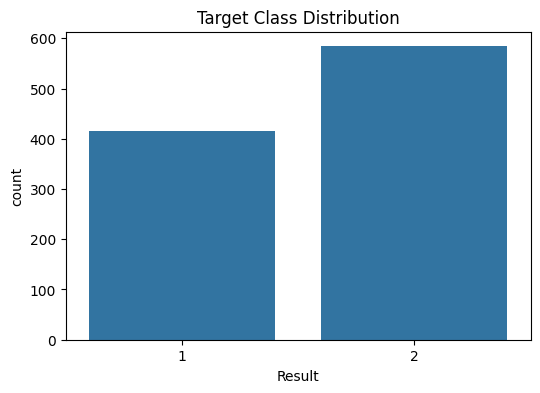

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Class distribution:\n", y.value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()

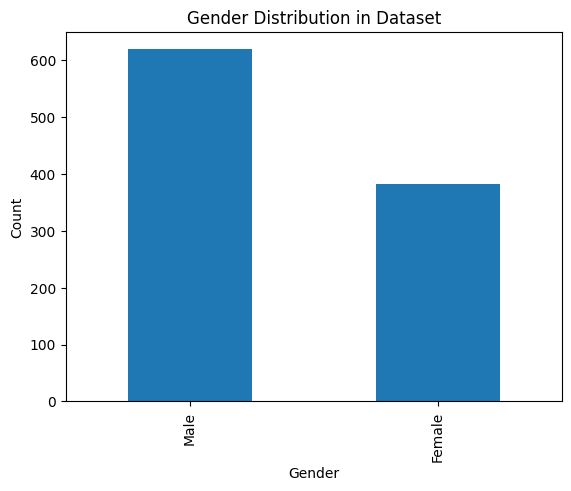

In [13]:
df["Gender"].value_counts().plot(kind="bar")

plt.xticks([0,1], ["Male","Female"])
plt.ylabel("Count")
plt.title("Gender Distribution in Dataset")

plt.show()